# 04_02 Classification - RandomForest with CrossValidator

Train and evaluate RandomForestClassifier using k-fold CrossValidator (3-fold) for hyperparameter tuning.

**Note:** This notebook uses CrossValidator (k-fold CV) instead of TrainValidationSplit, satisfying UTIL-04 requirement.
**Important:** RandomForest runs with parallelism=1 to avoid OOM.


## [COMMAND_SO]

Command 1

[COMMAND_MUC_DICH]

- Muc tieu nghiep vu: Train RandomForest voi CrossValidator (3-fold) va so sanh voi TVS.
- Muc tieu ky thuat: RF chay tuan tu (parallelism=1) de tranh OOM, grid size nho.


In [2]:
from pathlib import Path
import json
from pyspark.sql import SparkSession
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import time

# Spark session setup
spark = (SparkSession.builder
    .appName('04_02_rf_cv')
    .master('local[2]')
    .config('spark.sql.shuffle.partitions','16')
    .getOrCreate())
spark.sparkContext.setLogLevel('WARN')

# Paths
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
FEATURE_DIR = PROJECT_ROOT / 'data' / 'processed' / 'features'
MODEL_DIR = PROJECT_ROOT / 'models' / 'classification' / 'random_forest_cv_best'
METRIC_DIR = PROJECT_ROOT / 'reports' / 'model_metrics'
CROSSVAL_DIR = METRIC_DIR / 'crossvalidator'

MODEL_DIR.mkdir(parents=True, exist_ok=True)
METRIC_DIR.mkdir(parents=True, exist_ok=True)
CROSSVAL_DIR.mkdir(parents=True, exist_ok=True)

# Load data
train_df = spark.read.parquet(str(FEATURE_DIR / 'classification_train')).select('order_id','label','features').dropna()
val_df = spark.read.parquet(str(FEATURE_DIR / 'classification_val')).select('order_id','label','features').dropna()
test_df = spark.read.parquet(str(FEATURE_DIR / 'classification_test')).select('order_id','label','features').dropna()

print(f"Train rows: {train_df.count()}, Val rows: {val_df.count()}, Test rows: {test_df.count()}")

Train rows: 68887, Val rows: 14546, Test rows: 14734


## Setup CrossValidator with ParamGrid

**CrossValidator Configuration:**

- numFolds=3 (k-fold cross-validation)
- Grid: numTrees=[10, 50], maxBins=[16, 32] (2x2 = 4 combinations)
- Metric: Accuracy (for CV optimization)
- parallelism=1 (RF must run sequentially to avoid OOM)


In [3]:
# Define model
rf = RandomForestClassifier(featuresCol='features', labelCol='label', seed=42, maxDepth=8)

# Build param grid (2x2 = 4 combinations - smaller for RF)
param_grid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [10, 50])
    .addGrid(rf.maxBins, [16, 32])
    .build()
)

print(f"Total param combinations: {len(param_grid)}")

# Evaluator for CV
cv_evaluator = MulticlassClassificationEvaluator(
    labelCol='label',
    predictionCol='prediction',
    metricName='accuracy'
)

# CrossValidator setup - NOTE: parallelism=1 for RF
cv = CrossValidator(
    estimator=rf,
    estimatorParamMaps=param_grid,
    evaluator=cv_evaluator,
    numFolds=3,  # KEY: 3-fold cross-validation
    seed=42,
    parallelism=1  # CRITICAL: RF must run sequentially to avoid OOM
)

print("CrossValidator configured:")
print(f"  - numFolds: 3")
print(f"  - parallelism: 1 (sequential - prevents OOM)")
print(f"  - param combinations: {len(param_grid)}")
print(f"  - total models trained: {len(param_grid) * 3}")

Total param combinations: 4
CrossValidator configured:
  - numFolds: 3
  - parallelism: 1 (sequential - prevents OOM)
  - param combinations: 4
  - total models trained: 12


## Run CrossValidator

This will train 12 models (4 param combos x 3 folds) sequentially and select the best.


In [4]:
# Fit CrossValidator
start_time = time.time()
print("Training CrossValidator (3-fold, sequential for RF)...")
print("⚠️ This may take longer due to sequential training (parallelism=1)")

cv_model = cv.fit(train_df)

training_time = time.time() - start_time
print(f"Training completed in {training_time:.2f} seconds")

# Get best model
best_model = cv_model.bestModel
best_numTrees = best_model.getNumTrees # type: ignore
best_maxBins = best_model.getOrDefault('maxBins')

print(f"\nBest params found:")
print(f"  numTrees: {best_numTrees}")
print(f"  maxBins: {best_maxBins}")

Training CrossValidator (3-fold, sequential for RF)...
⚠️ This may take longer due to sequential training (parallelism=1)
Training completed in 10.91 seconds

Best params found:
  numTrees: 10
  maxBins: 16


## Display All Param Combinations with CV Scores


In [5]:
# Extract param combinations and their avg CV scores
param_combos = []
for i, params in enumerate(param_grid):
    num_trees = params[rf.numTrees]
    max_bins = params[rf.maxBins]
    avg_score = cv_model.avgMetrics[i]
    param_combos.append({
        'numTrees': num_trees,
        'maxBins': max_bins,
        'cv_avg_accuracy': float(avg_score)
    })

cv_results_df = pd.DataFrame(param_combos)
cv_results_df = cv_results_df.sort_values('cv_avg_accuracy', ascending=False)

print("All parameter combinations with CV scores (sorted by accuracy):")
display(cv_results_df)

# Save detailed CV results
cv_results_df.to_csv(CROSSVAL_DIR / 'cv_random_forest.csv', index=False)
print(f"\nSaved to: {CROSSVAL_DIR / 'cv_random_forest.csv'}")

All parameter combinations with CV scores (sorted by accuracy):


,numTrees,maxBins,cv_avg_accuracy
0,10,16,0.77148
1,10,32,0.77148
2,50,16,0.77148
3,50,32,0.77148



Saved to: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/reports/model_metrics/crossvalidator/cv_random_forest.csv


## Evaluate Best Model on Validation and Test Sets


In [6]:
# Evaluate best model
pred_val = best_model.transform(val_df)
pred_test = best_model.transform(test_df)

# Metrics
val_f1 = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='f1').evaluate(pred_val)
val_acc = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='accuracy').evaluate(pred_val)
test_f1 = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='f1').evaluate(pred_test)
test_acc = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='accuracy').evaluate(pred_test)

# CV average metric for best params
best_cv_avg = max(cv_model.avgMetrics)

metrics = {
    'model_family': 'classification',
    'model_name': 'RandomForest_CV',
    'tuning_method': 'CrossValidator',
    'num_folds': 3,
    'best_numTrees': int(best_numTrees),
    'best_maxBins': int(best_maxBins),
    'cv_avg_accuracy': float(best_cv_avg),
    'val_f1': float(val_f1),
    'val_accuracy': float(val_acc),
    'test_f1': float(test_f1),
    'test_accuracy': float(test_acc),
    'train_rows': train_df.count(),
    'val_rows': val_df.count(),
    'test_rows': test_df.count(),
    'training_time_seconds': float(training_time),
    'total_combinations': len(param_grid)
}

print("\nFinal Metrics:")
print(metrics)
display(pd.DataFrame([metrics]))


Final Metrics:
{'model_family': 'classification', 'model_name': 'RandomForest_CV', 'tuning_method': 'CrossValidator', 'num_folds': 3, 'best_numTrees': 10, 'best_maxBins': 16, 'cv_avg_accuracy': 0.7714802330648376, 'val_f1': 0.6674715852898907, 'val_accuracy': 0.7681836931115084, 'test_f1': 0.6786282662928452, 'test_accuracy': 0.7763675851771413, 'train_rows': 68887, 'val_rows': 14546, 'test_rows': 14734, 'training_time_seconds': 10.911885023117065, 'total_combinations': 4}


,model_family,model_name,tuning_method,num_folds,best_numTrees,best_maxBins,cv_avg_accuracy,val_f1,val_accuracy,test_f1,test_accuracy,train_rows,val_rows,test_rows,training_time_seconds,total_combinations
0,classification,RandomForest_CV,CrossValidator,3,10,16,0.77148,0.667472,0.768184,0.678628,0.776368,68887,14546,14734,10.911885,4


## Confusion Matrix


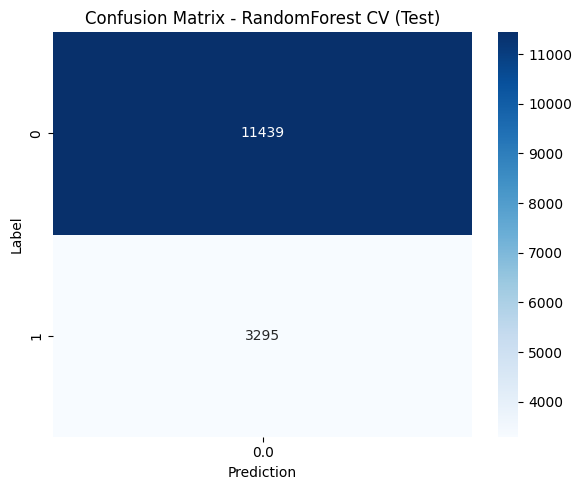

In [7]:
cm_pdf = pred_test.groupBy('label', 'prediction').count().toPandas()
if not cm_pdf.empty:
    cm_table = cm_pdf.pivot(index='label', columns='prediction', values='count').fillna(0).sort_index().sort_index(axis=1)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_table, annot=True, fmt='.0f', cmap='Blues')
    plt.title('Confusion Matrix - RandomForest CV (Test)')
    plt.xlabel('Prediction')
    plt.ylabel('Label')
    plt.tight_layout()
    plt.show()

## CrossValidator vs TrainValidationSplit Comparison


In [8]:
# Load TVS results
tvs_path = METRIC_DIR / 'classification_random_forest.json'
tvs_metrics = {}
if tvs_path.exists():
    with open(tvs_path) as f:
        tvs_data = json.load(f)
    tvs_metrics = {
        'tvs_val_accuracy': tvs_data.get('val_accuracy', 'N/A'),
        'tvs_test_accuracy': tvs_data.get('test_accuracy', 'N/A'),
        'tvs_test_f1': tvs_data.get('test_f1', 'N/A')
    }

# Create comparison
comparison = {
    'metric': ['Test Accuracy', 'Test F1-Score'],
    'CrossValidator_CV': [
        f"{test_acc:.4f}",
        f"{test_f1:.4f}"
    ],
    'TrainValidationSplit': [
        f"{tvs_metrics.get('tvs_test_accuracy', 'N/A')}",
        f"{tvs_metrics.get('tvs_test_f1', 'N/A')}"
    ],
    'winner': [
        'CV' if test_acc > tvs_metrics.get('tvs_test_accuracy', 0) else 'TVS',
        'CV' if test_f1 > tvs_metrics.get('tvs_test_f1', 0) else 'TVS'
    ]
}

comparison_df = pd.DataFrame(comparison)
print("CrossValidator vs TrainValidationSplit Comparison:")
display(comparison_df)

# Save comparison
comparison_df.to_csv(CROSSVAL_DIR / 'cv_vs_tvs_random_forest.csv', index=False)

print(f"\nNotes:")
print(f"- CV avg accuracy ({best_cv_avg:.4f}) is average across 3 folds")
print(f"- CV is more stable but slower than TVS")
print(f"- RF uses parallelism=1 to prevent OOM")

CrossValidator vs TrainValidationSplit Comparison:


,metric,CrossValidator_CV,TrainValidationSplit,winner
0,Test Accuracy,0.7764,0.7763675851771413,TVS
1,Test F1-Score,0.6786,0.6786282662928452,TVS



Notes:
- CV avg accuracy (0.7715) is average across 3 folds
- CV is more stable but slower than TVS
- RF uses parallelism=1 to prevent OOM


## Save Model and Metrics


In [9]:
# Save best model
best_model.write().overwrite().save(str(MODEL_DIR))
print(f"Best model saved to: {MODEL_DIR}")

# Save metrics
metrics_path = METRIC_DIR / 'classification_random_forest_cv.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f"Metrics saved to: {metrics_path}")

# Save tuning report
tuning_report = {
    'model_family': 'classification',
    'model_name': 'RandomForest',
    'tuning_method': 'CrossValidator',
    'num_folds': 3,
    'metric': 'accuracy',
    'avgMetrics': [float(x) for x in cv_model.avgMetrics],
    'bestParams': {
        'numTrees': int(best_numTrees),
        'maxBins': int(best_maxBins)
    },
    'parallelism': 1,
    'note': 'RF runs sequentially to avoid OOM'
}

tuning_path = METRIC_DIR / 'tuning_classification_random_forest_cv.json'
with open(tuning_path, 'w') as f:
    json.dump(tuning_report, f, indent=2)
print(f"Tuning report saved to: {tuning_path}")

print("\n✅ CrossValidator training complete!")

Best model saved to: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/models/classification/random_forest_cv_best
Metrics saved to: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/reports/model_metrics/classification_random_forest_cv.json
Tuning report saved to: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/reports/model_metrics/tuning_classification_random_forest_cv.json

✅ CrossValidator training complete!
